# Identificador de hablantes con Mini Xi-vector y MLP

Este notebook entrena y exporta el modelo de identificación de hablantes usado por el firmware del ESP32-S3. El enfoque es híbrido: primero se aplica procesamiento digital de audio para extraer MFCC, luego se resumen esas características en un Mini Xi-vector estadístico de 80 valores y finalmente se entrena un MLP ligero para clasificar el hablante.

La idea central es no entrenar la red con audio crudo. En su lugar, el notebook transforma cada segmento de voz en una representación compacta y estable:

```text
Audio WAV -> Segmentos de 2 s -> MFCC -> Mini Xi-vector de 80 valores -> Normalización -> MLP -> Exportación TFLite INT8
```

Orden recomendado de ejecución:

1. Ejecutar el bloque de procesamiento para generar `X_xvector.npy`, `y_labels.npy`, `labels.npy` y los parámetros de normalización.
2. Ejecutar el bloque de entrenamiento para crear, evaluar y exportar el modelo.
3. Ejecutar el bloque de visualización si se quieren inspeccionar ejemplos del dataset.

Nota importante: las celdas de código se mantienen como fuente de verdad. Estas explicaciones solo organizan el notebook y describen qué hace cada etapa.


## 1. Procesamiento del dataset y extracción de características

Esta primera celda toma los audios de `../dataset_fam`, detecta automáticamente las carpetas de hablantes y convierte cada archivo WAV en ejemplos numéricos listos para entrenar.

Entradas principales:

| Entrada | Descripción |
| --- | --- |
| `../dataset_fam/` | Carpeta con una subcarpeta por hablante |
| WAV por persona | Audios originales usados para entrenamiento |
| `sampling_rate = 16000` | Frecuencia de muestreo usada también por el ESP32 |
| `segment_duration = 2` | Duración de cada segmento de entrenamiento |
| `step_segment = samples_segment // 4` | Salto de 0.5 s entre segmentos |

### 1.1 Registro del proceso

La clase `Logger` redirige la salida de consola a `procesamiento_log.txt`. Esto permite conservar un historial del procesamiento: clases encontradas, cantidad de segmentos, balanceo y archivos generados.

### 1.2 Carga automática de hablantes

El notebook busca carpetas dentro de `dataset_fam`. Cada carpeta representa una clase. Por ejemplo:

```text
dataset_fam/hija
dataset_fam/hijo
dataset_fam/mama
dataset_fam/papa
```

El orden de las clases se guarda en `labels.npy`. Ese orden es importante porque debe coincidir con `src/speaker_labels.h` en el firmware.

### 1.3 Preprocesamiento del audio

El audio se normaliza para parecerse al flujo del ESP32. La función `audio_normalized_esp32()` simula parte del tratamiento que se hace en firmware: filtrado, escalado y limitación de amplitud. La función `normalizar_volumen()` ayuda a que los audios tengan un nivel más consistente antes de extraer características.

### 1.4 Segmentación

Cada audio se divide en ventanas de 2 segundos con salto de 0.5 segundos. Esto aumenta la cantidad de ejemplos y permite que el modelo aprenda con distintas partes de una misma grabación.

```text
Audio largo -> segmentos superpuestos de 2 segundos
```

### 1.5 Filtro de energía

Antes de calcular MFCC, se descartan segmentos con poca energía. Esto evita entrenar con silencio o ruido débil que no representa bien la identidad del hablante.

### 1.6 MFCC compatible con firmware

La función `calculoMFCC()` reproduce el pipeline acústico que también existe en `src/MFCC.cpp`:

```text
Preénfasis -> Ventana Hamming -> FFT -> Potencia -> Filtros Mel -> Log -> DCT
```

El resultado es una matriz MFCC de 20 bandas. Para el modelo se usan 63 frames centrales, igual que en el firmware.

### 1.7 Mini Xi-vector

La función `extract_xvector_features()` convierte la matriz MFCC en un vector de 80 características. Para cada una de las 20 bandas Mel calcula:

1. Media
2. Desviación estándar
3. Máximo
4. Mínimo

Por eso:

```text
20 bandas x 4 estadísticas = 80 características
```

Este vector estadístico resume la forma espectral del hablante y reduce mucho la cantidad de datos que debe procesar el MLP.

### 1.8 Balanceo y normalización

El código limita la cantidad máxima de segmentos por clase para evitar que un hablante domine el entrenamiento. Luego usa `StandardScaler` para normalizar las características y guardar la media y desviación estándar que después se copian al firmware.

Salidas generadas:

| Archivo | Uso |
| --- | --- |
| `X_xvector.npy` | Características normalizadas de entrenamiento |
| `y_labels.npy` | Etiquetas numéricas por segmento |
| `labels.npy` | Nombres de hablantes en orden de clase |
| `xvector_mean.npy` | Media para normalización |
| `xvector_std.npy` | Desviación estándar para normalización |
| `normalizacion_params.txt` | Valores usados para actualizar `src/normalizacion.h` |
| `procesamiento_log.txt` | Registro completo del procesamiento |


In [ ]:
import os
import numpy as np
import soundfile as sf
from scipy.fftpack import dct
import random
import sys

# ==============================
# LOGGER
# ==============================

class Logger:
    def __init__(self, filename="procesamiento_log.txt"):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding="utf-8")
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.log.flush()
    def flush(self):
        pass

sys.stdout = Logger()

# ==============================
# CONFIG
# ==============================

dataset_path = "../dataset_fam"
# NO cargamos ruido

sampling_rate = 16000
segment_duration = 2
samples_segment = sampling_rate * segment_duration
step_segment = samples_segment // 4  # 0.5s salto

Mel_bands = 20
Size_win = 512
Size_off = 256
frec_min = 20
frec_max = sampling_rate // 2

energia_umbral = 0.0025
MAX_SEGMENTOS = 700
TARGET_RMS = 0.065

# ==============================
# PREPROCESAMIENTO - EXACTAMENTE IGUAL QUE ESP32 v3.3
# ==============================

def audio_normalized_esp32(raw_signal):
    """
    EXACTAMENTE el mismo preprocesamiento que el ESP32 v3.3 / grabador v10.1.
    
    El grabador hace:
        int32_t raw = i2s_buffer[i] & 0xFFFFFF00;
        float current_raw = (float)(raw >> 14);
        float filtered = 0.995f * (last_filtered + current_raw - last_raw);
        int16_t val = (int16_t)(filtered * 2.0f);
    
    El ESP32 identificador hace:
        normalized_signal[j] = (filtered * 2.0f) / 32768.0f;
    """
    BUFLEN = len(raw_signal)
    normalized_signal = np.zeros(BUFLEN, dtype=np.float32)
    
    last_filtered = 0.0
    last_raw = 0.0
    
    for j in range(BUFLEN):
        # EXACTAMENTE igual que el grabador/ESP32
        raw = int(raw_signal[j]) & 0xFFFFFF00
        current_raw = float(raw >> 14)
        
        # Filtro paso alto identico
        filtered = 0.995 * (last_filtered + current_raw - last_raw)
        last_raw = current_raw
        last_filtered = filtered
        
        # Escalar a [-1, 1] igual que el ESP32
        normalized_signal[j] = (filtered * 2.0) / 32768.0
        
        # Clip de seguridad
        normalized_signal[j] = max(-1.0, min(1.0, normalized_signal[j]))
    
    return normalized_signal

def normalizar_volumen(audio, target_rms=TARGET_RMS):
    current_rms = np.sqrt(np.mean(audio**2))
    if current_rms > 0:
        audio = audio * (target_rms / current_rms)
    return np.clip(audio, -1.0, 1.0)

# ==============================
# MFCC (sin librosa) - IGUAL QUE MFCC.cpp
# ==============================

def calculoMFCC(audio):
    audio = audio.astype(np.float32).copy()
    for i in range(len(audio) - 1, 0, -1):
        audio[i] = audio[i] - audio[i-1] * 0.97
    
    frames = []
    for i in range(0, len(audio) - Size_win + 1, Size_off):
        frames.append(audio[i:i+Size_win])
    
    frames = np.array(frames, dtype=np.float32)
    hamming = 0.53836 - 0.46164 * np.cos((2.0 * np.pi * np.arange(Size_win)) / (Size_win - 1))
    frames = frames * hamming
    
    fft = np.fft.rfft(frames, Size_win)
    power = np.abs(fft) ** 2  # Igual que MFCC.cpp: (r*r + im*im)
    
    # Filtros triangulares Mel
    mel_min = 2595 * np.log10(1 + frec_min / 700)
    mel_max = 2595 * np.log10(1 + frec_max / 700)
    mel_points = np.linspace(mel_min, mel_max, Mel_bands + 2)
    hz = 700 * (10 ** (mel_points / 2595) - 1)
    bins = np.floor(((Size_win / 2) + 1) * hz / frec_max).astype(int)
    
    fbank = np.zeros((Mel_bands, int(Size_win / 2 + 1)), dtype=np.float32)
    for m in range(1, Mel_bands + 1):
        f1, f2, f3 = bins[m-1], bins[m], bins[m+1]
        for k in range(f1, f2):
            fbank[m-1, k] = (k - f1) / (f2 - f1 + 1e-9)
        for k in range(f2, f3):
            fbank[m-1, k] = (f3 - k) / (f3 - f2 + 1e-9)
    
    mel = np.dot(power, fbank.T)
    log_mel = np.log(mel + 1e-6)  # Igual que MFCC.cpp
    mfcc = dct(log_mel, type=2, axis=1, norm='ortho')
    mfcc = mfcc.T  # Shape: (Mel_bands, num_frames)
    
    # Centrar a 63 ventanas (igual que MFCC.cpp)
    if mfcc.shape[1] >= 63:
        start = (mfcc.shape[1] - 63) // 2
        mfcc = mfcc[:, start:start+63]
    else:
        pad = 63 - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (pad//2, pad - pad//2)), mode='constant')
    
    return mfcc

# ==============================
# Xi-VECTOR FEATURES
# ==============================

def extract_xvector_features(mfcc):
    features = []
    for band in range(Mel_bands):
        band_data = mfcc[band, :]
        features.append(np.mean(band_data))
        features.append(np.std(band_data))
        features.append(np.max(band_data))
        features.append(np.min(band_data))
    
    return np.array(features, dtype=np.float32)

# ==============================
# PROCESAR DATASET (SIN RUIDO)
# ==============================

personas = sorted([d for d in os.listdir(dataset_path) 
                   if os.path.isdir(os.path.join(dataset_path, d))])
print("Clases encontradas:", personas)

X = []
y = []

for label, persona in enumerate(personas):
    print(f"\n{'='*50}")
    print(f"PROCESANDO: {persona} (clase {label})")
    print(f"{'='*50}")
    
    persona_path = os.path.join(dataset_path, persona)
    archivos = [f for f in os.listdir(persona_path) if f.endswith(".wav")]
    print(f"  Archivos encontrados: {len(archivos)}")
    
    segs = []
    
    for archivo in archivos:
        print(f"  -> {archivo}")
        try:
            audio, sr = sf.read(os.path.join(persona_path, archivo), dtype='float32')
            if len(audio.shape) > 1:
                audio = np.mean(audio, axis=1)
            if sr != sampling_rate:
                from scipy.signal import resample
                audio = resample(audio, int(len(audio) * sampling_rate / sr))
            
            # Convertir a int32 como viene del ESP32 (WAV es int16 guardado como float32)
            # El WAV del grabador tiene: int16_t val = (int16_t)(filtered * 2.0f)
            # Para reconstruir el int32 que el ESP32 leeria:
            audio_int32 = (audio * 32768).astype(np.int32)
            
            # Aplicar EXACTAMENTE el mismo preprocesamiento que el ESP32
            audio_proc = audio
            
            # Normalizar volumen
            #audio_proc = normalizar_volumen(audio_proc)
            
            n_segs = 0
            for i in range(0, len(audio_proc) - samples_segment + 1, step_segment):
                seg = audio_proc[i:i + samples_segment]
                energia = np.mean(np.abs(seg))
                if energia < energia_umbral:
                    continue
                
                # SIN DATA AUGMENTATION DE RUIDO
                
                mfcc = calculoMFCC(seg)
                if mfcc.shape == (Mel_bands, 63):
                    xvec_features = extract_xvector_features(mfcc)
                    segs.append(xvec_features)
                    n_segs += 1
            
            print(f"    Segmentos extraidos: {n_segs}")
        except Exception as e:
            print(f"    [ERROR] {archivo}: {e}")
    
    print(f"  Total segmentos antes de balancear: {len(segs)}")
    
    if len(segs) > MAX_SEGMENTOS:
        print(f"  -> Limitando a {MAX_SEGMENTOS} segmentos")
        segs = random.sample(segs, MAX_SEGMENTOS)
    
    print(f"  Segmentos finales: {len(segs)}")
    
    for feat in segs:
        X.append(feat)
        y.append(label)

# ==============================
# NORMALIZAR Y GUARDAR
# ==============================

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\n{'='*50}")
print("DATASET FINAL (SIN RUIDO)")
print(f"{'='*50}")
print(f"Forma X: {X.shape}")
print(f"Forma y: {y.shape}")
print(f"Clases: {personas}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mean = scaler.mean_
std = scaler.scale_

print(f"\nEstadisticas (por feature):")
print(f"  Mean range: [{np.min(mean):.4f}, {np.max(mean):.4f}]")
print(f"  Std range:  [{np.min(std):.4f}, {np.max(std):.4f}]")

np.save("X_xvector.npy", X_scaled)
np.save("y_labels.npy", y)
np.save("labels.npy", personas)
np.save("xvector_mean.npy", mean)
np.save("xvector_std.npy", std)

with open("normalizacion_params.txt", "w") as f:
    f.write("// Xi-Vector normalization params\n")
    f.write(f"const int XVEC_DIM = {len(mean)};\n")
    f.write("const float XVEC_MEAN[] = {")
    f.write(", ".join([f"{m:.8f}f" for m in mean]))
    f.write("};\n")
    f.write("const float XVEC_STD[] = {")
    f.write(", ".join([f"{s:.8f}f" for s in std]))
    f.write("};\n")

from collections import Counter
print("\nDistribucion final:")
for label, count in sorted(Counter(y).items()):
    print(f"  {personas[label]}: {count}")

print("\nArchivos guardados:")
print("   - X_xvector.npy")
print("   - y_labels.npy")
print("   - labels.npy")
print("   - xvector_mean.npy")
print("   - xvector_std.npy")
print("   - normalizacion_params.txt")

Clases encontradas: ['hija', 'hijo', 'mama', 'papa']

PROCESANDO: hija (clase 0)
  Archivos encontrados: 8
  -> hija_1_discucion_1.wav
    Segmentos extraidos: 36
  -> hija_1_discucion_2.wav
    Segmentos extraidos: 36
  -> hija_1_discucion_3.wav
    Segmentos extraidos: 37
  -> hija_1_gustos.wav
    Segmentos extraidos: 37
  -> hija_1_molestia.wav
    Segmentos extraidos: 37
  -> hija_1_rutina.wav
    Segmentos extraidos: 37
  -> hija_1_saludo.wav
    Segmentos extraidos: 37
  -> hija_1_vacaciones.wav
    Segmentos extraidos: 37
  Total segmentos antes de balancear: 294
  Segmentos finales: 294

PROCESANDO: hijo (clase 1)
  Archivos encontrados: 8
  -> hijo_1_discucion_1.wav
    Segmentos extraidos: 36
  -> hijo_1_discucion_2.wav
    Segmentos extraidos: 36
  -> hijo_1_discucion_3.wav
    Segmentos extraidos: 37
  -> hijo_1_gustos.wav
    Segmentos extraidos: 37
  -> hijo_1_molestia.wav
    Segmentos extraidos: 37
  -> hijo_1_rutina.wav
    Segmentos extraidos: 37
  -> hijo_1_saludo.w


Estadisticas (por feature):
  Mean range: [-34.8239, 8.0054]
  Std range:  [0.0874, 6.3843]

Distribucion final:
  hija: 294
  hijo: 292
  mama: 295
  papa: 295

Archivos guardados:
   - X_xvector.npy
   - y_labels.npy
   - labels.npy
   - xvector_mean.npy
   - xvector_std.npy
   - normalizacion_params.txt
Dataset: (1176, 80), Clases: ['hija' 'hijo' 'mama' 'papa']
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 80)]              0         
                                                                 
 dense (Dense)               (None, 128)               10368     
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)     

## 2. Resultado esperado del procesamiento

Al terminar esta celda deben existir los archivos `.npy` y `normalizacion_params.txt` dentro de `Train/`. Si se agregaron nuevos hablantes o cambió el dataset, conviene revisar especialmente:

1. Que `labels.npy` tenga las clases correctas.
2. Que `X_xvector.npy` tenga 80 columnas.
3. Que `normalizacion_params.txt` se actualice con la nueva media y desviación estándar.
4. Que el log no muestre clases vacías o segmentos descartados en exceso.

Estos archivos son la entrada directa del bloque de entrenamiento.


## 3. Entrenamiento, evaluación y exportación del modelo

Esta celda carga los Xi-vectors generados en el procesamiento, entrena un MLP y exporta el modelo para usarlo en el ESP32-S3 con TensorFlow Lite Micro.

Entradas principales:

| Archivo | Descripción |
| --- | --- |
| `X_xvector.npy` | Matriz de características de forma `(segmentos, 80)` |
| `y_labels.npy` | Clase numérica de cada segmento |
| `labels.npy` | Nombre de cada clase |

### 3.1 División entrenamiento-validación

El dataset se divide con `train_test_split(..., test_size=0.2, stratify=y)`. Esto deja 80% para entrenamiento y 20% para validación, manteniendo la proporción de clases.

### 3.2 Balanceo por pesos de clase

`compute_class_weight()` calcula pesos para compensar diferencias de cantidad entre hablantes. Si una clase tiene menos ejemplos, el entrenamiento puede darle más peso para reducir sesgo.

### 3.3 Arquitectura MLP de Mini Xi-vector

El modelo es un MLP porque usa capas densas conectadas hacia adelante. Su entrada no es audio crudo ni una imagen de espectrograma: su entrada es el Mini Xi-vector de 80 características.

Arquitectura:

```text
Input(80)
-> Dense(128, ReLU)
-> BatchNormalization
-> Dropout(0.3)
-> Dense(64, ReLU, name="xvector_embedding")
-> BatchNormalization
-> Dropout(0.3)
-> Dense(32, ReLU)
-> Dropout(0.2)
-> Dense(num_classes, Softmax)
```

Función de cada bloque:

| Bloque | Propósito |
| --- | --- |
| `Dense(128)` | Aprende combinaciones no lineales entre estadísticas MFCC |
| `BatchNormalization` | Estabiliza activaciones durante entrenamiento |
| `Dropout` | Reduce sobreajuste apagando conexiones durante entrenamiento |
| `xvector_embedding` | Representación neuronal intermedia de la identidad del hablante |
| `Dense(32)` | Compacta la información antes de clasificar |
| `Softmax` | Convierte la salida en probabilidades por hablante |

La salida tiene `num_classes` neuronas. En el entrenamiento actual son cuatro clases: `hija`, `hijo`, `mama` y `papa`.

### 3.4 Compilación y callbacks

El modelo se compila con `sparse_categorical_crossentropy`, que es adecuada porque las etiquetas son enteros. Se usa `Adam` como optimizador y `accuracy` como métrica.

Los callbacks ayudan a controlar el entrenamiento:

| Callback | Función |
| --- | --- |
| `EarlyStopping` | Detiene el entrenamiento cuando ya no mejora la validación |
| `ReduceLROnPlateau` | Reduce el learning rate si la pérdida de validación se estanca |

### 3.5 Evaluación

Después del entrenamiento se calcula accuracy de validación, reporte de clasificación y matriz de confusión. La matriz de confusión permite detectar si dos hablantes se están confundiendo entre sí.

### 3.6 Exportación

La celda genera varios formatos del modelo:

| Archivo | Uso |
| --- | --- |
| `xvector_model.h5` | Modelo Keras original |
| `xvector_model.tflite` | Modelo TensorFlow Lite en float |
| `xvector_model_int8.tflite` | Modelo cuantizado INT8 |
| `modelo_hablante.h` | Arreglo C para incluir en firmware |
| `confusion_matrix_xvector.png` | Imagen de evaluación |

El archivo más importante para el ESP32 es `modelo_hablante.h`, pero también se debe mantener sincronizado `src/normalizacion.h` con los parámetros de normalización generados en el procesamiento.


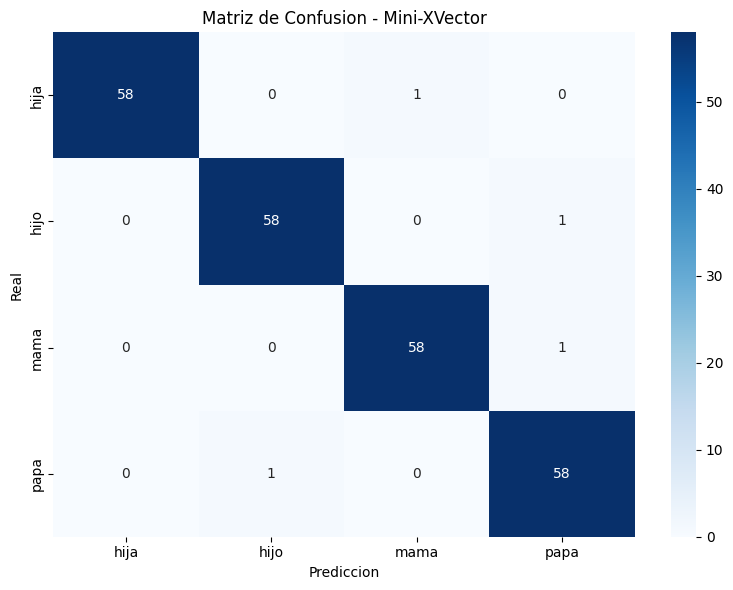

INFO:tensorflow:Assets written to: C:\Users\EALO4\AppData\Local\Temp\tmpvspstlrw\assets
INFO:tensorflow:Assets written to: C:\Users\EALO4\AppData\Local\Temp\tmp45mdxkv6\assets
c:\Users\EALO4\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


In [2]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# CARGAR DATOS
# ==============================

X = np.load("X_xvector.npy")
y = np.load("y_labels.npy")
labels = np.load("labels.npy", allow_pickle=True)

print(f"Dataset: {X.shape}, Clases: {labels}")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# ==============================
# MODELO MINI-XiVECTOR
# ==============================

def crear_modelo_xvector(num_classes, input_dim=80):
    inputs = tf.keras.Input(shape=(input_dim,))
    
    x = tf.keras.layers.Dense(128, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(64, activation='relu', name="xvector_embedding")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = crear_modelo_xvector(len(labels))
model.summary()

total_params = model.count_params()
print(f"\n{'='*50}")
print(f"TOTAL PARAMETROS: {total_params:,}")
print(f"Tamaño estimado FP32: {total_params * 4 / 1024:.1f} KB")
print(f"Tamaño estimado INT8: {total_params * 1 / 1024:.1f} KB")
print(f"{'='*50}")

# ==============================
# ENTRENAR
# ==============================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ==============================
# EVALUAR
# ==============================

val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"\n{'='*50}")
print(f"VALIDATION ACCURACY: {val_acc:.4f}")
print(f"{'='*50}")

y_pred = np.argmax(model.predict(X_val), axis=1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=labels))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusion - Mini-XVector')
plt.ylabel('Real')
plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig('confusion_matrix_xvector.png', dpi=150)
plt.show()

# ==============================
# GUARDAR Y EXPORTAR
# ==============================

model.save("xvector_model.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_float = converter.convert()

with open("xvector_model.tflite", "wb") as f:
    f.write(tflite_float)

print(f"\nTamaño TFLite (float): {len(tflite_float)/1024:.1f} KB")

def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_int8 = converter_int8.convert()

with open("xvector_model_int8.tflite", "wb") as f:
    f.write(tflite_int8)

print(f"Tamaño TFLite (INT8): {len(tflite_int8)/1024:.1f} KB")

def tflite_to_h(tflite_data, filename, varname):
    with open(filename, "w") as f:
        f.write(f"#ifndef {varname.upper()}_H\n")
        f.write(f"#define {varname.upper()}_H\n\n")
        f.write(f"const unsigned int {varname}_len = {len(tflite_data)};\n\n")
        f.write(f"const unsigned char {varname}[] = {{\n")
        
        for i in range(0, len(tflite_data), 12):
            line = tflite_data[i:i+12]
            f.write("    " + ", ".join(f"0x{b:02x}" for b in line) + ",\n")
        
        f.write("};\n\n")
        f.write(f"#endif\n")
    
    print(f"Generado: {filename} ({len(tflite_data)/1024:.1f} KB)")

tflite_to_h(tflite_int8, "modelo_hablante.h", "modelo_hablante_tflite")

print("\nArchivos generados:")
print("   - xvector_model.h5")
print("   - xvector_model.tflite")
print("   - xvector_model_int8.tflite")
print("   - modelo_hablante.h")
print("   - confusion_matrix_xvector.png")

## 4. Resultado esperado del entrenamiento

Al terminar esta celda se espera tener un modelo entrenado, evaluado y exportado. Para integrar el resultado en firmware:

1. Copiar `Train/modelo_hablante.h` hacia `src/modelo_hablante.h`.
2. Actualizar `src/normalizacion.h` con los valores de `Train/normalizacion_params.txt`.
3. Verificar que `src/speaker_labels.h` coincida con `Train/labels.npy`.
4. Compilar y subir el firmware con PlatformIO.

Si la accuracy baja mucho o la matriz de confusión muestra errores repetidos entre dos hablantes, conviene revisar el dataset antes de subir el modelo al ESP32.


## 5. Visualización de muestras de audio

Esta celda no entrena ni exporta el modelo. Sirve para inspeccionar ejemplos del dataset usando el mismo procesamiento de características que se usa durante el entrenamiento.

La visualización reutiliza las funciones definidas en la celda de procesamiento:

1. Carga el audio con `soundfile`.
2. Convierte a mono si es necesario.
3. Remuestrea a 16 kHz si el archivo tiene otra frecuencia.
4. Selecciona segmentos de 2 segundos con el mismo salto usado en entrenamiento.
5. Aplica el mismo filtro de energía.
6. Calcula MFCC con `calculoMFCC()`.
7. Extrae el Mini Xi-vector con `extract_xvector_features()`.

Esto permite revisar las muestras con el mismo criterio que usa el modelo y mantiene coherencia con el pipeline real del proyecto.


In [1]:
import os
import random
import soundfile as sf
from scipy.signal import resample
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CONFIG
# ============================================

required_functions = ["calculoMFCC", "extract_xvector_features"]
missing_functions = [name for name in required_functions if name not in globals()]

if missing_functions:
    raise RuntimeError(
        "Ejecuta primero la celda de procesamiento para definir: "
        + ", ".join(missing_functions)
    )

DATASET_DIR = dataset_path if "dataset_path" in globals() else "../dataset_fam"
SR = sampling_rate if "sampling_rate" in globals() else 16000
SEGMENT_SECONDS = segment_duration if "segment_duration" in globals() else 2
SEGMENT_SAMPLES = samples_segment if "samples_segment" in globals() else SR * SEGMENT_SECONDS
STEP_SAMPLES = step_segment if "step_segment" in globals() else SEGMENT_SAMPLES // 4
ENERGY_THRESHOLD = energia_umbral if "energia_umbral" in globals() else 0.0025
MEL_BANDS_VIEW = Mel_bands if "Mel_bands" in globals() else 20

# ============================================
# FUNCIONES AUXILIARES
# ============================================

def cargar_audio_entrenamiento(audio_path):
    audio, sr = sf.read(audio_path, dtype="float32")

    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)

    if sr != SR:
        audio = resample(audio, int(len(audio) * SR / sr)).astype(np.float32)

    return audio.astype(np.float32)


def seleccionar_segmento_valido(audio):
    if len(audio) < SEGMENT_SAMPLES:
        return None

    candidatos = []

    for start in range(0, len(audio) - SEGMENT_SAMPLES + 1, STEP_SAMPLES):
        seg = audio[start:start + SEGMENT_SAMPLES]
        energia = np.mean(np.abs(seg))

        if energia >= ENERGY_THRESHOLD:
            candidatos.append((start, seg, energia))

    if not candidatos:
        return None

    return random.choice(candidatos)

# ============================================
# OBTENER CARPETAS
# ============================================

speaker_folders = sorted([
    os.path.join(DATASET_DIR, d)
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

print("HABLANTES ENCONTRADOS:")
for speaker_path in speaker_folders:
    print("-", os.path.basename(speaker_path))

# ============================================
# VISUALIZAR CON EL MISMO MFCC DEL ENTRENAMIENTO
# ============================================

for speaker_path in speaker_folders:
    speaker_name = os.path.basename(speaker_path)

    wav_files = sorted([
        os.path.join(speaker_path, f)
        for f in os.listdir(speaker_path)
        if f.lower().endswith(".wav")
    ])

    if not wav_files:
        continue

    selected_files = random.sample(wav_files, min(2, len(wav_files)))

    for audio_path in selected_files:
        audio = cargar_audio_entrenamiento(audio_path)
        selected = seleccionar_segmento_valido(audio)

        if selected is None:
            print(f"[AVISO] Sin segmento valido por energia: {audio_path}")
            continue

        start_sample, segment, energia = selected
        mfcc = calculoMFCC(segment)
        xvec = extract_xvector_features(mfcc)

        print()
        print("===================================")
        print("HABLANTE:", speaker_name)
        print("AUDIO:", os.path.basename(audio_path))
        print(f"SEGMENTO: {start_sample / SR:.2f}s - {(start_sample + SEGMENT_SAMPLES) / SR:.2f}s")
        print(f"ENERGIA: {energia:.6f}")
        print(f"MFCC: {mfcc.shape}")
        print(f"Mini Xi-vector: {xvec.shape}")
        print("===================================")

        time_axis = np.arange(len(segment)) / SR

        fig, ax = plt.subplots(3, 1, figsize=(12, 8))

        ax[0].plot(time_axis, segment, linewidth=0.8)
        ax[0].set_title(f"Waveform - {speaker_name}")
        ax[0].set_xlabel("Tiempo (s)")
        ax[0].set_ylabel("Amplitud")
        ax[0].grid(True, alpha=0.25)

        img = ax[1].imshow(
            mfcc,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            extent=[0, SEGMENT_SECONDS, 0, MEL_BANDS_VIEW]
        )
        ax[1].set_title("MFCC calculado con calculoMFCC()")
        ax[1].set_xlabel("Tiempo (s)")
        ax[1].set_ylabel("Banda MFCC")
        plt.colorbar(img, ax=ax[1], label="Coeficiente")

        ax[2].plot(np.arange(len(xvec)), xvec, linewidth=1.2)
        ax[2].set_title("Mini Xi-vector: media, std, maximo y minimo por banda")
        ax[2].set_xlabel("Indice de caracteristica")
        ax[2].set_ylabel("Valor")
        ax[2].grid(True, alpha=0.25)

        plt.tight_layout()
        plt.show()


RuntimeError: Ejecuta primero la celda de procesamiento para definir: calculoMFCC, extract_xvector_features

## 6. Checklist final

Antes de usar el modelo en el ESP32-S3 N16R8, revisar:

1. `labels.npy` contiene las clases esperadas y en el orden correcto.
2. `X_xvector.npy` tiene 80 características por segmento.
3. `normalizacion_params.txt` corresponde al último procesamiento.
4. `modelo_hablante.h` fue copiado a `src/modelo_hablante.h`.
5. `src/normalizacion.h` fue actualizado con los nuevos valores.
6. `src/speaker_labels.h` fue regenerado desde `Train/generate_speaker_labels.py`.
7. La matriz de confusión no muestra confusiones críticas.
8. En el Monitor Serial se revisan tiempos de MFCC, inferencia, total, RAM y PSRAM.
